# Introduction to Ocean Modelling : Exercise 6

### Elsie Chilwane (CHLMOT003) 

### 2/06/2026

### Marcello Vichi 

DISCLAIMER: AI was used in following way:

https://claude.ai/share/fca3c7cf-767e-4653-9d7e-153d2676597d

# **Exercise 6**

In [3]:
import numpy as np
import matplotlib.pyplot as plt


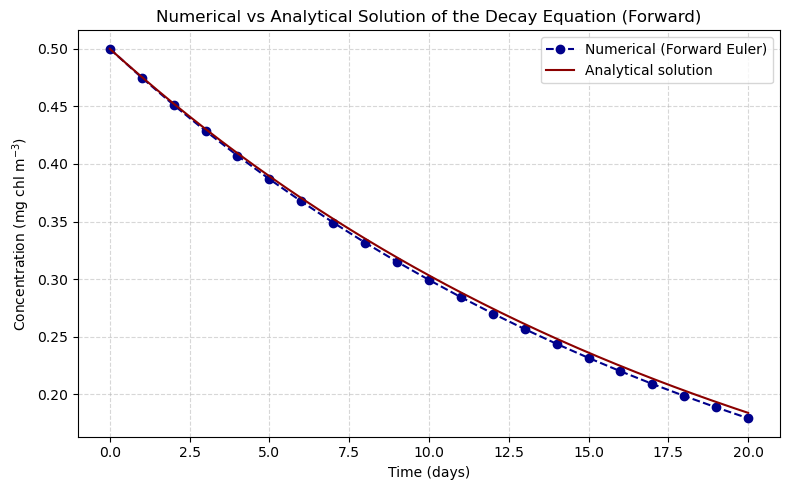

In [4]:
"""
A numerical solution of the decay equation.
"""
t0 = 0.       # time is in days
tn = 20.
dt = 1.
kappa = 0.05  # day^-1
C0 = 0.5      # mg chl/m3

def F(k, C):  # define the function for the right hand side of the equation
    return -k * C

# compute the total number of steps
Ntot = int(np.floor((tn - t0) / dt) + 1)

# initialization
C = np.zeros(Ntot)
t = C.copy()  # this array stores the time and has the same size as C
t[0] = t0
C[0] = C0

# start the loop
for n in range(Ntot - 1):
    C[n+1] = C[n] + F(kappa, C[n]) * dt
    t[n+1] = t[n] + dt

# analytical solution for comparison
t_exact = np.linspace(t0, tn, 200)
C_exact = C0 * np.exp(-kappa * t_exact)

# plot
fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(t, C, 'o--', color='darkblue', label='Numerical (Forward Euler)')
ax.plot(t_exact, C_exact, '-', color='darkred', label='Analytical solution')

ax.set_xlabel('Time (days)')
ax.set_ylabel('Concentration (mg chl m$^{-3}$)')
ax.set_title('Numerical vs Analytical Solution of the Decay Equation (Forward)')
ax.legend()
ax.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

**Figure 1: Numerical vs Analytical Solution of the Decay Equation taken from the Lecture Notes (Forward Euler)**

Modify the Euler-forward method implemented in the codes at the
beginning of this section (either the python or matlab version) and change
it into the Euler-backward method.
• Compare the results for different values of ∆t and upload your code and
results on the GitHub repository.

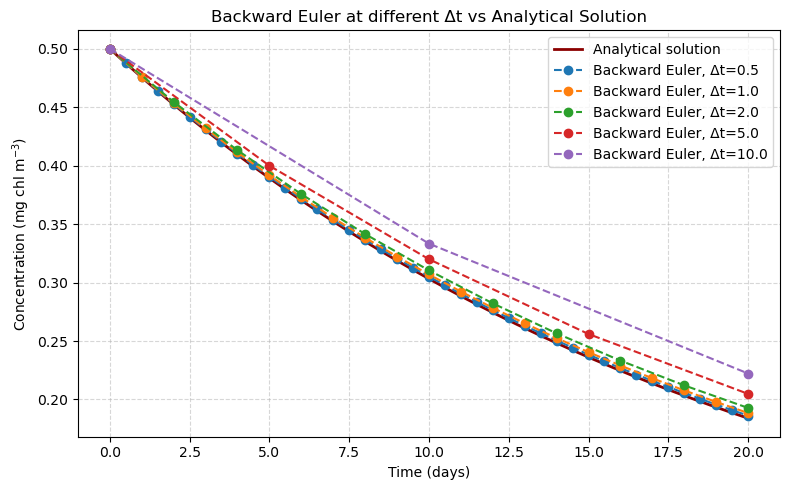

In [5]:

t0 = 0.       # time is in days
tn = 20.
dt = 1.
kappa = 0.05  # day^-1
C0 = 0.5      # mg chl/m3

def F(k, C):  # right hand side of the equation
    return -k * C

t_exact = np.linspace(t0, tn, 200)
C_exact = C0 * np.exp(-kappa * t_exact)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(t_exact, C_exact, '-', color='darkred', linewidth=2, label='Analytical solution')

for dt in [0.5, 1.0, 2.0, 5.0, 10.0]:
    Ntot = int(np.floor((tn - t0)/dt) + 1)
    C = np.zeros(Ntot)
    t = np.zeros(Ntot)
    C[0] = C0
    G = 1.0 / (1.0 + kappa*dt)       
    for n in range(Ntot - 1):
        C[n+1] = G * C[n]             
        t[n+1] = t[n] + dt
    ax.plot(t, C, 'o--', label=f'Backward Euler, Δt={dt}')

ax.set_xlabel('Time (days)')
ax.set_ylabel('Concentration (mg chl m$^{-3}$)')
ax.set_title('Backward Euler at different Δt vs Analytical Solution')
ax.legend()
ax.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

**Figure 2: Backward Euler at different Δt vs analytical solution (Backward Euler)**

The forward and backward Euler schemes differ in how their numerical solutions sit either below or above the analytical curve.

Forward Euler decays slightly too quickly, so it undershoots the concentration and its numerical curve lies below the analytical solution.
Backward Euler decays slightly too slowly, so it overshoots the concentration and its numerical curve lies above the analytical solution. 
As the timestep Δt increases, this error grows and the numerical curves move further from the analytical solution but backward Euler remains stable and keeps decaying at every Δt, even at Δt = 10, this confirms its unconditional stability.

**The error increases with the size of the timestep: larger Δt produces larger truncation error per step, so the numerical curve deviates further from the analytical solution. Within each run, these per-step errors also accumulate over time.** ~ Claude AI input. 